# Detección de intrusiones de red con aprendizaje automático y XAI para pymes de Juliaca

**Autor:** Fernando Ccolla Lazarinos · **Curso:** Seminario de Tesis II · **Protocolo:** V2 · **Corrida oficial:** `RUN_REPRO_V2_03_CLEANROOM`

Este cuaderno es una **versión representativa y ejecutable** de la experimentación. Reproduce el procedimiento completo
(auditoría → validación cruzada → selección → test → SHAP → alerta/playbook) sobre una **muestra estratificada reducida de GeNIS 2025**
(20,000 flujos de entrenamiento y 5,000 de prueba, semilla 42), de modo que corre en pocos minutos y no requiere los datasets completos (≈1 GB).

| Parte | Qué contiene | Fuente de los números |
|---|---|---|
| 1–7 | Pipeline ejecutado en vivo | **Muestra reducida** (se recalcula al ejecutar) |
| 8 | Resultados de la corrida completa (GeNIS 607,933 flujos; CICIDS2017) | **Archivos oficiales** en `resultados_oficiales/` |

> Los valores de la muestra pueden diferir ligeramente de los oficiales; los oficiales son los que sustentan la tesis.
> La evaluación con usuarios (OE4) **no está ejecutada**: corresponde a la fase siguiente.

In [1]:
import json, time, warnings, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn, xgboost, shap, imblearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
import xgboost as xgb
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
GOLD, GRAY = "#B8934A", "#8A9099"

DATA, OFICIAL = Path("data"), Path("resultados_oficiales")
CLASES = ["benign", "bruteforce", "dos", "recon"]
SEED = 42
print("Python", platform.python_version(), "| sklearn", sklearn.__version__, "| xgboost", xgboost.__version__,
      "| shap", shap.__version__, "| imblearn", imblearn.__version__)

Python 3.11.9 | sklearn 1.9.0 | xgboost 3.2.0 | shap 0.51.0 | imblearn 0.14.2


## 1. Datos y auditoría

GeNIS se usa como conjunto principal con su **partición oficial train/test** (no se vuelve a mezclar). CICIDS2017 se usa solo como repetición independiente (parte 8).
Aquí se carga la muestra estratificada y se contrasta con la auditoría oficial del dataset completo.

,Muestra (este cuaderno),Dataset completo (oficial)
train,20000,486346
test,5000,121587


Auditoría oficial → faltantes: {'train': 0, 'test': 0} | infinitos: {'train': 0, 'test': 0} | duplicados intra-split: {'train': 0, 'test': 0} | duplicados cruzados train/test: 0


,train (muestra),train (oficial),% muestra,% oficial
dos,17424,423700,87.12,87.12
benign,1070,26027,5.35,5.35
recon,912,22186,4.56,4.56
bruteforce,594,14433,2.97,2.97


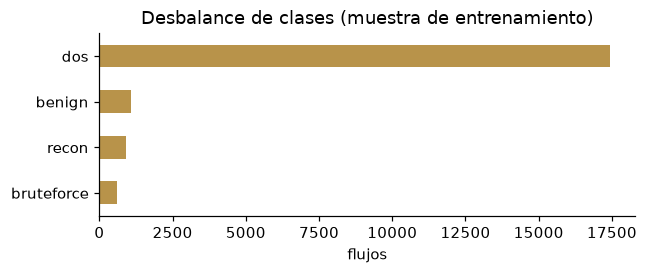

In [2]:
train = pd.read_csv(DATA / "genis_muestra_train.csv.gz")
test = pd.read_csv(DATA / "genis_muestra_test.csv.gz")
audit = json.load(open(OFICIAL / "dataset_audit_genis.json", encoding="utf-8"))

resumen = pd.DataFrame({
    "Muestra (este cuaderno)": [len(train), len(test)],
    "Dataset completo (oficial)": [audit["train_rows"], audit["test_rows"]],
}, index=["train", "test"])
display(resumen)

print("Auditoría oficial → faltantes:", audit["missing_values"], "| infinitos:", audit["infinite_values"],
      "| duplicados intra-split:", audit["intra_split_duplicates"], "| duplicados cruzados train/test:", audit["cross_split_exact_duplicates"])

dist = pd.DataFrame({
    "train (muestra)": train["CategoryLabel"].value_counts(),
    "train (oficial)": pd.Series(audit["train_class_distribution"]),
}).loc[["dos", "benign", "recon", "bruteforce"]]
display(dist.assign(**{"% muestra": (dist["train (muestra)"] / dist["train (muestra)"].sum() * 100).round(2),
                       "% oficial": (dist["train (oficial)"] / dist["train (oficial)"].sum() * 100).round(2)}))

ax = dist[["train (muestra)"]].plot.barh(color=GOLD, legend=False, figsize=(6, 2.6))
ax.invert_yaxis(); ax.set_title("Desbalance de clases (muestra de entrenamiento)"); ax.set_xlabel("flujos")
plt.tight_layout(); plt.show()

La clase **DoS domina (~87 %)**. Por eso la métrica principal es **F1-macro** (todas las clases pesan igual) y el balanceo se hace **dentro de cada fold**.

## 2. Pipeline sin fuga de información (*leakage*)

Orden dentro de cada fold: **selector de características → StandardScaler → submuestreo de la clase mayoritaria + SMOTE → clasificador**.
Todo se ajusta **solo con los 4 folds de entrenamiento**; el fold de validación solo se transforma y se predice.

- `FoldFeatureSelector`: elimina variables sin varianza y colineales (|r| ≥ 0.95).
- `SubsampledSMOTE`: ajuste documentado; la clase DoS agotaba la RAM con SMOTE directo, por lo que se submuestrea la mayoritaria (≤ 3× la segunda clase) antes de SMOTE.

In [3]:
class FoldFeatureSelector(BaseEstimator, TransformerMixin):
    """Selección dentro del fold: varianza cero y correlación de Pearson >= umbral."""
    def __init__(self, corr_threshold=0.95):
        self.corr_threshold = corr_threshold
        self.selected_features_ = None

    def fit(self, X, y=None):
        X_df = (X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)).replace([np.inf, -np.inf], np.nan)
        vars_ = X_df.var(axis=0, skipna=True)
        valid = vars_[vars_ > 1e-12].index.tolist() or X_df.columns.tolist()
        corr = X_df[valid].corr(method="pearson").abs()
        drop, cols = set(), valid
        for i, ci in enumerate(cols):
            if ci in drop:
                continue
            for cj in cols[i + 1:]:
                if cj in drop:
                    continue
                if corr.loc[ci, cj] >= self.corr_threshold:
                    vi, vj = vars_.get(ci, 0), vars_.get(cj, 0)
                    if vj < vi:
                        drop.add(cj)
                    elif vi < vj:
                        drop.add(ci); break
                    elif cj > ci:
                        drop.add(cj)
                    else:
                        drop.add(ci); break
        self.selected_features_ = [c for c in cols if c not in drop]
        return self

    def transform(self, X):
        X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        return X_df[self.selected_features_].replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy(dtype=np.float32)


class SubsampledSMOTE(BaseEstimator):
    """Submuestreo controlado de la clase mayoritaria y luego SMOTE (solo sobre train del fold)."""
    def __init__(self, majority_ratio=3.0, k_neighbors=5, random_state=42):
        self.majority_ratio, self.k_neighbors, self.random_state = majority_ratio, k_neighbors, random_state

    def fit_resample(self, X, y):
        counts = pd.Series(y).value_counts()
        target = int(min(counts.iloc[0], (counts.iloc[1] if len(counts) > 1 else counts.iloc[0]) * self.majority_ratio))
        strategy = {c: (target if c == counts.index[0] and n > target else n) for c, n in counts.items()}
        Xu, yu = RandomUnderSampler(sampling_strategy=strategy, random_state=self.random_state).fit_resample(X, y)
        k = max(1, min(self.k_neighbors, pd.Series(yu).value_counts().min() - 1))
        return SMOTE(k_neighbors=k, random_state=self.random_state).fit_resample(Xu, yu)


EXCLUIR = ["record_id", "BinaryLabel", "CategoryLabel", "SubCategoryLabel", "Sport", "Dport",
           "FlowID", "Rank", "Offset", "Seq", "StartTime", "LastTime"]   # identificadores / etiquetas
FEATURES = [c for c in train.columns if c not in EXCLUIR]
to_y = lambda s: s.map(CLASES.index).to_numpy()

X_train, y_train = train[FEATURES], to_y(train["CategoryLabel"])
X_test, y_test = test[FEATURES], to_y(test["CategoryLabel"])
print(f"{len(FEATURES)} variables candidatas · identificadores excluidos: {EXCLUIR[4:]}")


def make_model(name, params, seed=SEED):
    if name == "RandomForest":
        return RandomForestClassifier(n_jobs=-1, random_state=seed, **params)
    if name == "XGBoost":
        return xgb.XGBClassifier(tree_method="hist", n_jobs=-1, random_state=seed, eval_metric="mlogloss", **params)
    return MLPClassifier(early_stopping=True, random_state=seed, **params)


def make_pipeline(name, params, seed=SEED):
    return ImbPipeline([
        ("selector", FoldFeatureSelector(corr_threshold=0.95)),
        ("scaler", StandardScaler()),
        ("smote", SubsampledSMOTE(random_state=seed)),
        ("clf", make_model(name, params, seed)),
    ])

80 variables candidatas · identificadores excluidos: ['Sport', 'Dport', 'FlowID', 'Rank', 'Offset', 'Seq', 'StartTime', 'LastTime']


## 3. Validación cruzada estratificada de 5 folds

Se evalúan los tres algoritmos con **F1-macro**. Para que el cuaderno corra rápido se usan **2 configuraciones por modelo** (la mejor de la corrida oficial y una alternativa);
la corrida oficial evaluó **24 configuraciones × 5 folds = 120 evaluaciones** (10 RF, 10 XGBoost, 4 MLP).

In [4]:
CONFIGS = {
    "RandomForest": [{"n_estimators": 150, "max_depth": 10, "min_samples_split": 5},     # mejor oficial
                     {"n_estimators": 100, "max_depth": 15, "min_samples_split": 2}],
    "XGBoost":      [{"n_estimators": 100, "max_depth": 6, "learning_rate": 0.1},        # mejor oficial
                     {"n_estimators": 50,  "max_depth": 6, "learning_rate": 0.1}],
    "MLP":          [{"hidden_layer_sizes": (128, 64), "alpha": 0.001,  "max_iter": 30}, # mejor oficial
                     {"hidden_layer_sizes": (64, 32),  "alpha": 0.0001, "max_iter": 30}],
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(skf.split(X_train, y_train))

filas = []
t0 = time.time()
for nombre, cfgs in CONFIGS.items():
    for k, cfg in enumerate(cfgs, 1):
        scores = []
        for tr, va in folds:                      # el fold de validación solo se transforma y predice
            pipe = make_pipeline(nombre, cfg).fit(X_train.iloc[tr], y_train[tr])
            scores.append(f1_score(y_train[va], pipe.predict(X_train.iloc[va]), average="macro"))
        filas.append({"modelo": nombre, "config": k, "params": cfg, "F1-macro (media)": np.mean(scores), "DE": np.std(scores)})
        print(f"{nombre:<13} cfg {k}: F1={np.mean(scores):.6f} ± {np.std(scores):.6f}")
print(f"Tiempo total CV: {time.time()-t0:.0f} s  ·  {len(filas)} configuraciones × 5 folds = {len(filas)*5} evaluaciones")
cv = pd.DataFrame(filas)

RandomForest  cfg 1: F1=0.999491 ± 0.000623


RandomForest  cfg 2: F1=0.999746 ± 0.000509


XGBoost       cfg 1: F1=0.999164 ± 0.000696


XGBoost       cfg 2: F1=0.998837 ± 0.000604


MLP           cfg 1: F1=0.994811 ± 0.001933


MLP           cfg 2: F1=0.993298 ± 0.004356
Tiempo total CV: 44 s  ·  6 configuraciones × 5 folds = 30 evaluaciones


## 4. Selección del modelo

Regla del protocolo: **F1-macro → desviación estándar → latencia**. Si la diferencia de F1-macro entre modelos es ≤ 0.005 hay *empate técnico* y decide la menor desviación estándar.

,modelo,params,F1-macro (media),DE
0,RandomForest,"{'n_estimators': 100, 'max_depth': 15, 'min_sa...",0.999746,0.000509
1,XGBoost,"{'n_estimators': 100, 'max_depth': 6, 'learnin...",0.999164,0.000696
2,MLP,"{'hidden_layer_sizes': (128, 64), 'alpha': 0.0...",0.994811,0.001933


Diferencia con el mejor: [0.0, 0.000582, 0.004935]
Modelo seleccionado: RandomForest  (empate técnico: True; criterio: menor desviación estándar)


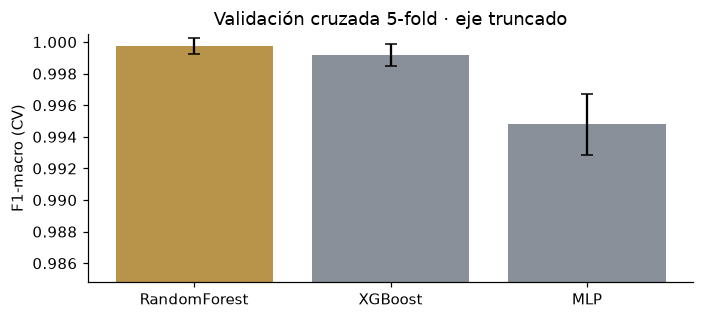

In [5]:
mejor = cv.sort_values("F1-macro (media)", ascending=False).groupby("modelo", sort=False).head(1).reset_index(drop=True)
display(mejor[["modelo", "params", "F1-macro (media)", "DE"]].round(6))

top = mejor.iloc[0]
empatados = mejor[(top["F1-macro (media)"] - mejor["F1-macro (media)"]) <= 0.005].sort_values("DE")
elegido = empatados.iloc[0]
print(f"Diferencia con el mejor: {(top['F1-macro (media)'] - mejor['F1-macro (media)']).round(6).tolist()}")
print(f"Modelo seleccionado: {elegido['modelo']}  (empate técnico: {len(empatados) > 1}; criterio: menor desviación estándar)")

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.bar(mejor["modelo"], mejor["F1-macro (media)"], yerr=mejor["DE"], color=[GOLD if m == elegido["modelo"] else GRAY for m in mejor["modelo"]], capsize=4)
ax.set_ylim(max(0, mejor["F1-macro (media)"].min() - 0.01), 1.0005); ax.set_ylabel("F1-macro (CV)")
ax.set_title("Validación cruzada 5-fold · eje truncado"); plt.tight_layout(); plt.show()

## 5. Evaluación en el test (5 semillas) y latencia (H3)

El modelo seleccionado se congela y se evalúa sobre el **test aislado** (nunca participó en selección, escalado ni SMOTE). Se repite con 5 semillas y se mide la latencia de inferencia **por flujo** (umbral H3: < 500 ms).

,F1-macro,Accuracy,Precision-macro,Recall-macro
semilla,,,,
42,0.999504,0.9998,0.999943,0.999067
52,0.999504,0.9998,0.999943,0.999067
62,0.999504,0.9998,0.999943,0.999067
72,1.000000,1.0000,1.000000,1.000000
82,0.999504,0.9998,0.999943,0.999067


,F1-macro,Accuracy,Precision-macro,Recall-macro
mean,0.999603,0.999840,0.999954,0.999254
std,0.000222,0.000089,0.000026,0.000417


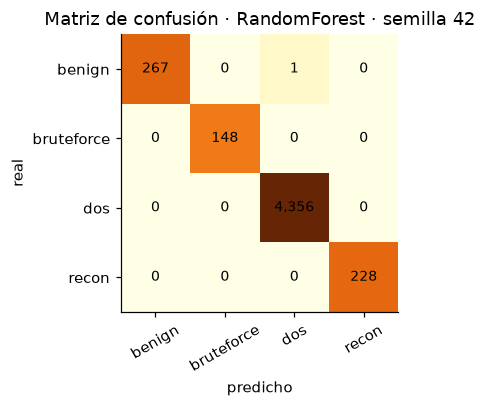

Latencia por flujo: media 33.12 ms · P95 35.60 ms · P99 37.07 ms  →  H3 (<500 ms): CUMPLE
La latencia depende del hardware: ver hardware_profile.json y environment_id en la parte 8.


In [6]:
modelo, params = elegido["modelo"], elegido["params"]
filas, preds_42 = [], None
for s in [42, 52, 62, 72, 82]:
    pipe = make_pipeline(modelo, params, seed=s).fit(X_train, y_train)
    p = pipe.predict(X_test)
    if s == 42:
        final_pipe, preds_42 = pipe, p
    filas.append({"semilla": s, "F1-macro": f1_score(y_test, p, average="macro"), "Accuracy": accuracy_score(y_test, p),
                  "Precision-macro": precision_score(y_test, p, average="macro"), "Recall-macro": recall_score(y_test, p, average="macro")})
res = pd.DataFrame(filas).set_index("semilla")
display(res.round(6)); display(res.agg(["mean", "std"]).round(6))

cm = confusion_matrix(y_test, preds_42, labels=range(4))
fig, ax = plt.subplots(figsize=(4.6, 3.8))
ax.imshow(np.log1p(cm), cmap="YlOrBr")
ax.set_xticks(range(4), CLASES, rotation=30); ax.set_yticks(range(4), CLASES)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=9)
ax.set_xlabel("predicho"); ax.set_ylabel("real"); ax.set_title(f"Matriz de confusión · {modelo} · semilla 42")
plt.tight_layout(); plt.show()

# Latencia por flujo (1 flujo por llamada, tras calentamiento)
muestra = X_test.sample(300, random_state=SEED)
for i in range(30):
    final_pipe.predict(muestra.iloc[[i]])
lat = []
for i in range(30, 300):
    t = time.perf_counter(); final_pipe.predict(muestra.iloc[[i]]); lat.append((time.perf_counter() - t) * 1000)
print(f"Latencia por flujo: media {np.mean(lat):.2f} ms · P95 {np.percentile(lat, 95):.2f} ms · P99 {np.percentile(lat, 99):.2f} ms  →  H3 (<500 ms): {'CUMPLE' if np.mean(lat) < 500 else 'NO CUMPLE'}")
print("La latencia depende del hardware: ver hardware_profile.json y environment_id en la parte 8.")

## 6. Explicabilidad con SHAP

`TreeExplainer` atribuye cada predicción a las variables. **Global**: qué variables pesan más en general (media de |SHAP|). **Local**: por qué se tomó una decisión concreta.
SHAP explica el comportamiento del *modelo*; **no demuestra causalidad** del ataque.

,importancia relativa
Sdaddr,0.1931
sHops,0.0636
DstWin,0.0482
SIntPktMin,0.0432
Dur,0.0392
dMaxPktSz,0.0387
SrcPkts,0.0381
TotBytes,0.0370
sTtl,0.0349
SrcBytes,0.0346


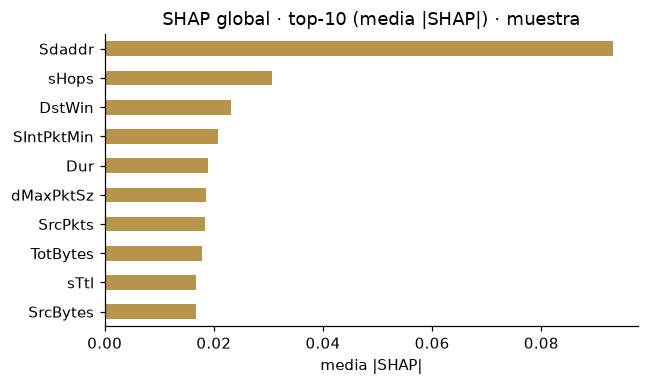

In [7]:
sel = final_pipe.named_steps["selector"]
clf = final_pipe.named_steps["clf"]
Xt = final_pipe.named_steps["scaler"].transform(sel.transform(X_test.iloc[:1000]))

if modelo == "MLP":
    raise SystemExit("MLP no usa TreeExplainer; el protocolo usa KernelExplainer (no incluido en la demo).")
explainer = shap.TreeExplainer(clf)
sv = explainer.shap_values(Xt)
sv = np.stack(sv, axis=-1) if isinstance(sv, list) else sv          # (n, features, clases)
global_imp = pd.Series(np.abs(sv).mean(axis=(0, 2)), index=sel.selected_features_).sort_values(ascending=False)
top10 = global_imp.head(10)
display((top10 / global_imp.sum()).rename("importancia relativa").to_frame().round(4))

ax = top10.iloc[::-1].plot.barh(color=GOLD, figsize=(6, 3.6))
ax.set_title("SHAP global · top-10 (media |SHAP|) · muestra"); ax.set_xlabel("media |SHAP|")
plt.tight_layout(); plt.show()

### De la predicción a la alerta y al playbook

Caso local: se toma un flujo clasificado como ataque, se listan las 3 variables que más empujaron la predicción y se asocia el playbook inicial.

In [8]:
PLAYBOOKS = {
    "dos": ("PB-01 · Mitigación de DoS", "Saturación SYN / UDP del enlace"),
    "recon": ("PB-02 · Aislamiento de reconocimiento", "Escaneo de puertos horizontal / vertical"),
    "bruteforce": ("PB-03 · Defensa de fuerza bruta", "Fuerza bruta de contraseñas / 2FA"),
}
pred = final_pipe.predict(X_test.iloc[:1000])
proba = final_pipe.predict_proba(X_test.iloc[:1000])
for clase in ["dos", "recon", "bruteforce"]:
    idx = np.where(pred == CLASES.index(clase))[0]
    if len(idx) == 0:
        continue
    i = idx[0]; c = CLASES.index(clase)
    top3 = pd.Series(sv[i, :, c], index=sel.selected_features_).sort_values(key=np.abs, ascending=False).head(3)
    pb, desc = PLAYBOOKS[clase]
    print(f"ALERTA · {clase.upper()}  (confianza {proba[i, c]*100:.2f} %)  — {desc}")
    for f, v in top3.items():
        print(f"   {f:<14} SHAP {v:+.4f}")
    print(f"   Playbook inicial: {pb}\n")

ALERTA · DOS  (confianza 100.00 %)  — Saturación SYN / UDP del enlace
   Sdaddr         SHAP +0.1905
   Dur            SHAP +0.0513
   SrcPkts        SHAP +0.0497
   Playbook inicial: PB-01 · Mitigación de DoS

ALERTA · RECON  (confianza 100.00 %)  — Escaneo de puertos horizontal / vertical
   sHops          SHAP +0.1254
   TotBytes       SHAP +0.0782
   SrcBytes       SHAP +0.0742
   Playbook inicial: PB-02 · Aislamiento de reconocimiento

ALERTA · BRUTEFORCE  (confianza 100.00 %)  — Fuerza bruta de contraseñas / 2FA
   SrcWin         SHAP +0.0788
   Sdaddr         SHAP +0.0681
   DstWin         SHAP +0.0498
   Playbook inicial: PB-03 · Defensa de fuerza bruta



## 7. Trazabilidad

Cada resultado oficial se asocia a hashes de datasets y scripts, configuraciones, folds, semillas, `environment_id`, modelos, predicciones, métricas, SHAP y logs
(ver `manifest_final.json` en la corrida y la carpeta `tesis_experimentos/` del repositorio).

In [9]:
lock = json.load(open(OFICIAL / "software_lock.json", encoding="utf-8"))
hw = json.load(open(OFICIAL / "hardware_profile.json", encoding="utf-8"))
print("environment_id (corrida oficial):", lock["environment_id"])
print("Hardware oficial:", hw["cpu"]["name"], f"· {hw['cpu']['physical_cores']}C/{hw['cpu']['logical_cores']}T · {hw['ram_gb']} GB RAM · CPU")
print("Librerías oficiales:", lock["packages"])

environment_id (corrida oficial): ENV_de6fe487a3e9
Hardware oficial: Intel(R) Core(TM) i5-10400 CPU @ 2.90GHz · 6C/12T · 7.92 GB RAM · CPU
Librerías oficiales: {'python': '3.11.9', 'scikit-learn': '1.9.0', 'xgboost': '3.2.0', 'shap': '0.51.0', 'imbalanced-learn': '0.14.2', 'pandas': '2.3.3', 'numpy': '2.4.0', 'psutil': '7.2.2', 'flask': '3.1.2'}


## 8. Resultados oficiales de la corrida completa

A partir de aquí **no se recalcula nada**: se leen los archivos generados por la corrida `RUN_REPRO_V2_03_CLEANROOM` (GeNIS completo y CICIDS2017).

### 8.1 GeNIS · validación cruzada y test oficial

,F1-macro CV (media),DE
RandomForest,0.999973,0.000054
XGBoost,0.999933,0.000085
MLP,0.999618,0.000204


Δ F1 RF–XGBoost = 0.00004  → empate técnico: True → seleccionado: RandomForest  (Menor desviacion estandar (DE=0.000054 vs 0.000085))
Hiperparámetros: {'n_estimators': 150, 'max_depth': 10, 'min_samples_split': 5} · 24 configuraciones × 5 folds = 120 evaluaciones

Test oficial (121,587 flujos, semillas [42, 52, 62, 72, 82]): F1-macro 0.999957 ± 0.000022 · Accuracy 0.999993
Matriz de confusión (semilla 42):


,benign,bruteforce,dos,recon
benign,6507,0,0,0
bruteforce,1,3607,0,0
dos,0,0,105925,0
recon,0,0,0,5547


H3: media 18.88 ms · P95 19.09 ms · P99 19.25 ms · umbral 500 ms · cumple: True (×26.49)


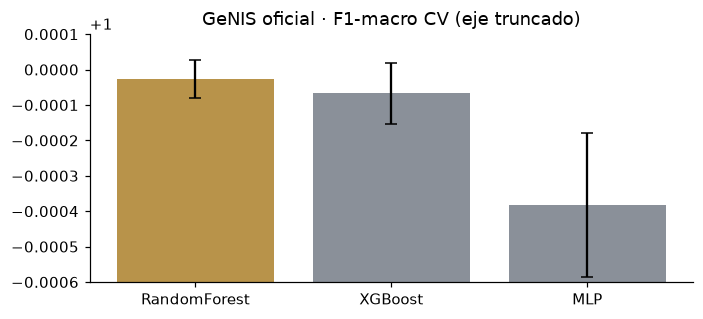

In [10]:
oe1 = json.load(open(OFICIAL / "oe1_definitive.json", encoding="utf-8"))
cvm = oe1["cv_evaluation_120_folds"]["models"]
tabla = pd.DataFrame({m: {"F1-macro CV (media)": v["f1_macro_mean"], "DE": v["f1_macro_std"]} for m, v in cvm.items()}).T
display(tabla.round(6))
d = oe1["selection_decision"]
print(f"Δ F1 RF–XGBoost = {d['delta_f1']:.5f}  → empate técnico: {d['is_tie']} → seleccionado: {d['selected_model']}  ({d['justification']})")
print("Hiperparámetros:", d["best_hyperparameters"], "· 24 configuraciones × 5 folds = 120 evaluaciones")

t = oe1["test_evaluation_5_seeds"]; ms = t["metrics_summary"]
print(f"\nTest oficial ({t['test_flows_count']:,} flujos, semillas {t['seeds']}): "
      f"F1-macro {ms['f1_macro_mean']:.6f} ± {ms['f1_macro_std']:.6f} · Accuracy {ms['accuracy_mean']:.6f}")
print("Matriz de confusión (semilla 42):"); display(pd.DataFrame(t["per_seed"]["42"]["confusion_matrix"], index=CLASES, columns=CLASES))
h3 = oe1["h3_latency_benchmark"]
print(f"H3: media {h3['mean_ms']:.2f} ms · P95 {h3['p95_ms']:.2f} ms · P99 {h3['p99_ms']:.2f} ms · umbral {h3['threshold_ms']:.0f} ms · cumple: {h3['meets_hypothesis']} (×{h3['margin_factor']})")

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.bar(tabla.index, tabla["F1-macro CV (media)"], yerr=tabla["DE"], color=[GOLD, GRAY, GRAY], capsize=4)
ax.set_ylim(0.9994, 1.0001); ax.set_title("GeNIS oficial · F1-macro CV (eje truncado)"); plt.tight_layout(); plt.show()

### 8.2 SHAP oficial en GeNIS

,feature,mean_abs_shap,relative_importance,cumulative_importance
0,Sdaddr,0.1024,0.2129,0.2129
1,sHops,0.0339,0.0704,0.2833
2,dMaxPktSz,0.0292,0.0607,0.3440
3,sTtl,0.0251,0.0521,0.3960
4,Dur,0.0196,0.0407,0.4368
5,SIntPktMin,0.0191,0.0397,0.4765
6,dMeanPktSz,0.0173,0.0359,0.5124
7,SrcBytes,0.0167,0.0348,0.5471
8,DstWin,0.0161,0.0335,0.5807
9,State_CON,0.0153,0.0317,0.6124


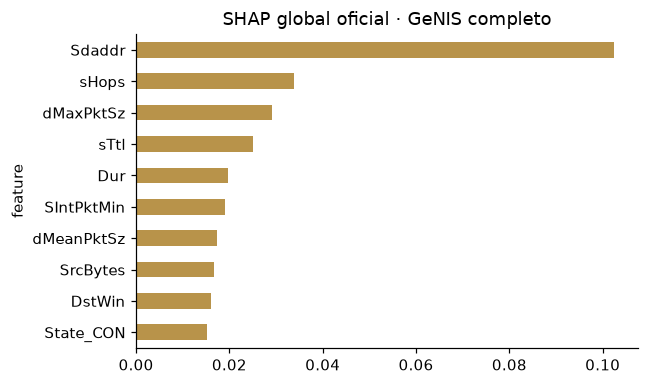

DOS         conf 100.00 %  PB-01 (DoS Mitigation)             ← Sdaddr (+0.205), Dur (+0.052), SIntPktMin (+0.047)
RECON       conf 100.00 %  PB-02 (Reconnaissance Isolation)   ← sHops (+0.141), sTtl (+0.086), SrcBytes (+0.071)
BRUTEFORCE  conf  99.90 %  PB-03 (Brute Force Defense)        ← dMaxPktSz (+0.067), Sdaddr (+0.063), State_CON (+0.052)

Nota: Sdaddr domina el ranking; queda como acción siguiente verificar que no actúe como identificador de la muestra.


In [11]:
shap_g = pd.read_csv(OFICIAL / "shap_top10_definitive.csv")
display(shap_g.round(4))
ax = shap_g.iloc[::-1].plot.barh(x="feature", y="mean_abs_shap", color=GOLD, legend=False, figsize=(6, 3.6))
ax.set_title("SHAP global oficial · GeNIS completo"); plt.tight_layout(); plt.show()

for caso in json.load(open(OFICIAL / "local_cases_definitive.json", encoding="utf-8")):
    f = ", ".join(f"{x['feature']} ({x['shap_value']:+.3f})" for x in caso["top_shap_factors"])
    print(f"{caso['pred_code'].upper():<11} conf {caso['confidence']*100:6.2f} %  {caso['playbook']:<34} ← {f}")
print("\nNota: Sdaddr domina el ranking; queda como acción siguiente verificar que no actúe como identificador de la muestra.")

### 8.3 CICIDS2017 (repetición independiente) y comparación homologada

CICIDS2017 **no participa en la selección del modelo de GeNIS**. Muestra estratificada de 99,996 flujos, split 80/20 (79,996 / 20,000), semilla 42.
Las explicaciones solo se comparan tras **homologar conceptos** (`feature_mapping.csv`): concepto, dirección, estadístico, unidad y ventana.

In [12]:
ci = json.load(open(OFICIAL / "cicids_oe1_metrics.json", encoding="utf-8"))
cmp_ = pd.DataFrame({"GeNIS": {m: v["f1_macro_mean"] for m, v in cvm.items()},
                     "CICIDS2017": {m: v["f1_macro_mean"] for m, v in ci["cv_metrics"].items()}}).round(5)
display(cmp_)
print(f"Ganador GeNIS: {oe1['selected_model']} · Ganador CICIDS: {ci['selected_model']} · F1-macro test CICIDS: {ci['test_f1_macro_mean']:.5f}")
print("Split CICIDS:", {k: v for k, v in json.load(open(OFICIAL / 'split_manifest.json', encoding='utf-8')).items() if k.endswith('_size')})

h2 = json.load(open(OFICIAL / "cross_dataset_shap_h2.json", encoding="utf-8"))
j5, j10 = h2["jaccard_top5"], h2["jaccard_top10"]
print(f"\nJaccard Top-5 = {j5['jaccard_index']}  (intersección: {j5['intersection']})  ·  Jaccard Top-10 = {j10['jaccard_index']}  ({j10['note']})")
print("J = |A ∩ B| / |A ∪ B| = 2/8 = 0.25 → solapamiento parcial; NO significa que los datasets sean 25 % iguales.")

,GeNIS,CICIDS2017
RandomForest,0.99997,0.97767
XGBoost,0.99993,0.98659
MLP,0.99962,0.90299


Ganador GeNIS: RandomForest · Ganador CICIDS: XGBoost · F1-macro test CICIDS: 0.98533
Split CICIDS: {'total_sample_size': 99996, 'train_size': 79996, 'test_size': 20000}

Jaccard Top-5 = 0.25  (intersección: ['bwd_max_pkt_size', 'tcp_win_init_bwd'])  ·  Jaccard Top-10 = N/A  (Variables homologables insuficientes para top-10 formal (§2.4).)
J = |A ∩ B| / |A ∪ B| = 2/8 = 0.25 → solapamiento parcial; NO significa que los datasets sean 25 % iguales.


## 9. Limitaciones y siguientes pasos

- **Ajustes respecto al protocolo:** submuestreo controlado de DoS antes de SMOTE (límite de RAM); lista congelada de 24 configuraciones en lugar de `RandomizedSearchCV` (reproducibilidad y control de recursos).
- **Por revisar:** el peso de `Sdaddr` en SHAP (posible identificador). CICIDS2017 es contraste independiente, no réplica de GeNIS.
- **Pendiente (OE4):** validación del instrumento (3 expertos, piloto con 2 usuarios) y evaluación exploratoria con 8–12 administradores de pymes de Juliaca. No hay resultados con usuarios en este trabajo.

**Detectar → explicar → traducir → apoyar una respuesta.**